# 04 - FxLMS Comparison
Comparación rigurosa: LMS (baseline) vs FxLMS (con modelado de entorno acústico).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.signal.generate_signal import generate_uav_signal
from src.anc.lms import LMS
from src.anc.fxlms import FxLMS
from src.simulation.secondary_path import generate_secondary_path, apply_secondary_path
from src.analysis.fft_analysis import compute_fft
from src.analysis.metrics import noise_reduction_db

fs = 8000
duration = 2
_, x, f_bpf = generate_uav_signal(fs=fs, duration=duration, rpm=6000, n_blades=2, seed=42)

# Generar secondary path simulado
h_sec = generate_secondary_path(length=32, delay_samples=2, attenuation=0.8, seed=42)
print(f'BPF teorica: {f_bpf:.2f} Hz')
print(f'Secondary path impulse response shape: {h_sec.shape}')
print(f'Secondary path delay: ~2 samples (~{2/fs*1000:.3f} ms)')

BPF teorica: 200.00 Hz
Secondary path impulse response shape: (32,)
Secondary path delay: ~2 samples (~0.250 ms)


In [3]:
# === LMS Baseline (referencia) ===
mu = 0.01
mu_fxlms = 0.01
filter_order = 64

model_lms = LMS(mu=mu, filter_order=filter_order)
e_lms_hist = []
y_lms_hist = []

for sample in x:
    y, e = model_lms.adapt(desired=sample, input_sample=sample)
    y_lms_hist.append(y)
    e_lms_hist.append(e)

e_lms = np.asarray(e_lms_hist)
reduction_lms = noise_reduction_db(original=x, error=e_lms)

print(f'LMS Reduccion de ruido: {reduction_lms:.2f} dB')

LMS Reduccion de ruido: 24.53 dB


In [4]:
# === FxLMS con modelado de secondary path ===
# FxLMS integrateseffects of loudspeaker + room dynamics
mu_fxlms = 0.01

model_fxlms = FxLMS(mu=mu_fxlms, filter_order=filter_order, secondary_path=h_sec)
e_fxlms_hist = []
y_fxlms_hist = []

for sample in x:
    y, e = model_fxlms.adapt(desired=sample, input_sample=sample)
    y_fxlms_hist.append(y)
    e_fxlms_hist.append(e)

e_fxlms = np.asarray(e_fxlms_hist)
reduction_fxlms = noise_reduction_db(original=x, error=e_fxlms)

print(f'FxLMS Reduccion de ruido: {reduction_fxlms:.2f} dB')
print(f'Diferencia vs LMS: {reduction_fxlms - reduction_lms:+.2f} dB (FxLMS modela entorno real)')

FxLMS Reduccion de ruido: 22.83 dB
Diferencia vs LMS: -1.70 dB (FxLMS modela entorno real)


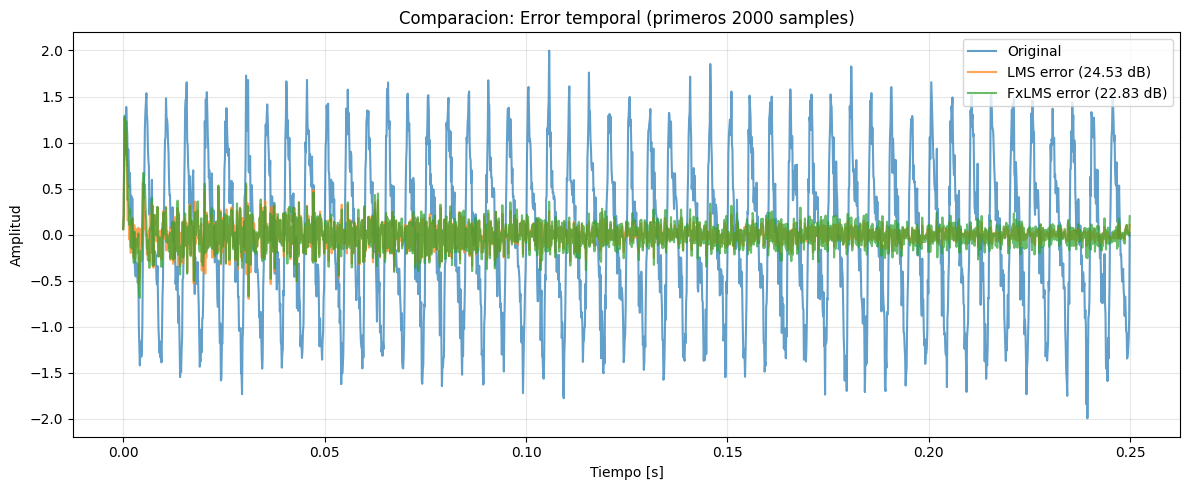

In [5]:
# === Grafica 1: Comparacion error temporal ===
n_show = min(2000, len(x))
t = np.arange(len(x)) / fs

plt.figure(figsize=(12, 5))
plt.plot(t[:n_show], x[:n_show], label='Original', alpha=0.7, linewidth=1.5)
plt.plot(t[:n_show], e_lms[:n_show], label=f'LMS error ({reduction_lms:.2f} dB)', alpha=0.7, linewidth=1.5)
plt.plot(t[:n_show], e_fxlms[:n_show], label=f'FxLMS error ({reduction_fxlms:.2f} dB)', alpha=0.7, linewidth=1.5)
plt.title('Comparacion: Error temporal (primeros 2000 samples)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

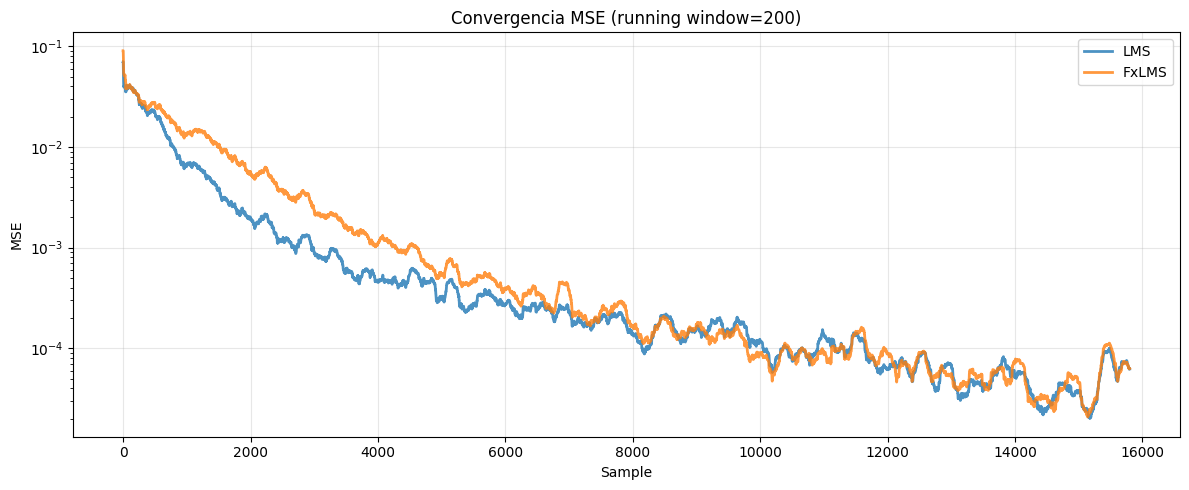

In [6]:
# === Grafica 2: Convergencia MSE (comparativo) ===
window = 200
running_mse_lms = np.convolve(e_lms**2, np.ones(window)/window, mode='valid')
running_mse_fxlms = np.convolve(e_fxlms**2, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(running_mse_lms, label='LMS', alpha=0.8, linewidth=2)
plt.plot(running_mse_fxlms, label='FxLMS', alpha=0.8, linewidth=2)
plt.title('Convergencia MSE (running window=200)')
plt.xlabel('Sample')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()

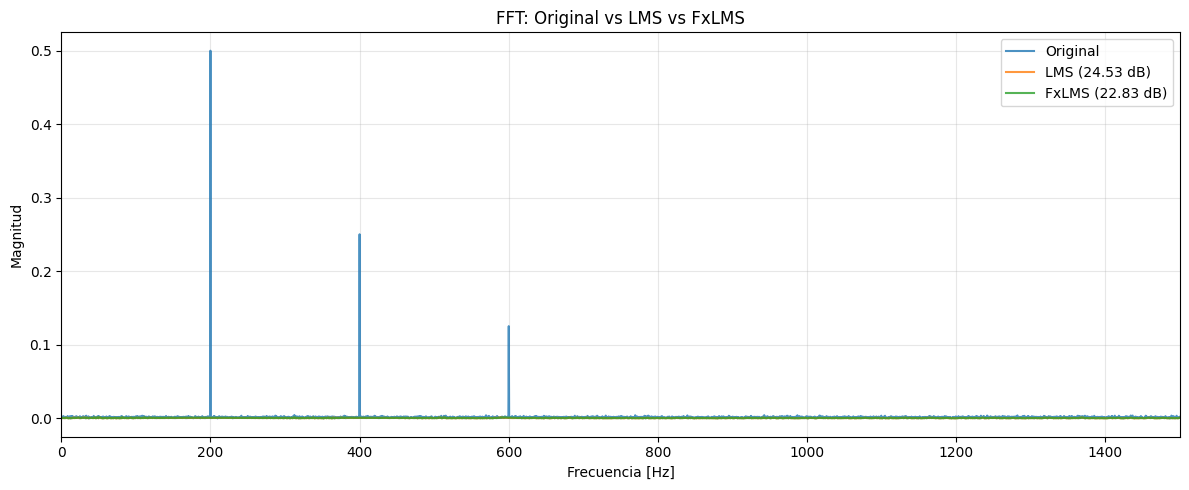

In [7]:
# === Grafica 3: FFT comparativa ===
freq_o, mag_o = compute_fft(x, fs)
freq_lms, mag_lms = compute_fft(e_lms, fs)
freq_fxlms, mag_fxlms = compute_fft(e_fxlms, fs)

plt.figure(figsize=(12, 5))
plt.plot(freq_o, mag_o, label='Original', alpha=0.8, linewidth=1.5)
plt.plot(freq_lms, mag_lms, label=f'LMS ({reduction_lms:.2f} dB)', alpha=0.8, linewidth=1.5)
plt.plot(freq_fxlms, mag_fxlms, label=f'FxLMS ({reduction_fxlms:.2f} dB)', alpha=0.8, linewidth=1.5)
plt.xlim(0, 1500)
plt.title('FFT: Original vs LMS vs FxLMS')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [8]:
# === Tabla comparativa final ===
print('\n===== RESULTADOS COMPARATIVOS =====')
print(f'\nMetrica            | LMS        | FxLMS      | Mejora')
print('-' * 60)
print(f'Reduccion (dB)     | {reduction_lms:8.2f}   | {reduction_fxlms:8.2f}   | {reduction_fxlms - reduction_lms:+8.2f}')

mse_lms_ini = np.mean(e_lms[:1000]**2)
mse_lms_fin = np.mean(e_lms[-1000:]**2)
mse_fxlms_ini = np.mean(e_fxlms[:1000]**2)
mse_fxlms_fin = np.mean(e_fxlms[-1000:]**2)

print(f'MSE inicial        | {mse_lms_ini:8.4f}   | {mse_fxlms_ini:8.4f}   | {mse_fxlms_ini - mse_lms_ini:+8.4f}')
print(f'MSE final          | {mse_lms_fin:8.6f}   | {mse_fxlms_fin:8.6f}   | {mse_fxlms_fin - mse_lms_fin:+8.6f}')

bpf_idx = np.argmin(np.abs(freq_o - f_bpf))
bpf_attenuation_lms = mag_o[bpf_idx] - mag_lms[bpf_idx]
bpf_attenuation_fxlms = mag_o[bpf_idx] - mag_fxlms[bpf_idx]
print(f'BPF atenuacion     | {bpf_attenuation_lms:8.4f}   | {bpf_attenuation_fxlms:8.4f}   | {bpf_attenuation_fxlms - bpf_attenuation_lms:+8.4f}')
print('\n===== FIN COMPARATIVA =====')


===== RESULTADOS COMPARATIVOS =====

Metrica            | LMS        | FxLMS      | Mejora
------------------------------------------------------------
Reduccion (dB)     |    24.53   |    22.83   |    -1.70
MSE inicial        |   0.0307   |   0.0382   |  +0.0075
MSE final          | 0.000052   | 0.000058   | +0.000006
BPF atenuacion     |   0.4998   |   0.4996   |  -0.0002

===== FIN COMPARATIVA =====
